# PCA

Principal Component Analysis on California housing features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data_df = pd.read_csv("housing.csv")
data_df['total_bedrooms'] = data_df['total_bedrooms'].fillna(data_df['total_bedrooms'].median())
data_df = pd.get_dummies(data_df, columns=['ocean_proximity'], dtype=float)

target = data_df['median_house_value'].to_numpy()
X = data_df.drop(columns=['median_house_value']).to_numpy()
feature_names = list(data_df.drop(columns=['median_house_value']).columns)

scaler = StandardScaler()
X = scaler.fit_transform(X)

print(X.shape, len(feature_names))

(20640, 13) 13


## Full decomposition

Run PCA with all components. Each component is an eigenvector of the covariance matrix:

$$\Sigma = \frac{1}{n-1} X^T X, \quad \Sigma v_i = \lambda_i v_i$$

Variance ratio is $\lambda_i / \sum_j \lambda_j$, and the cumulative curve tells me how many PCs are actually needed.

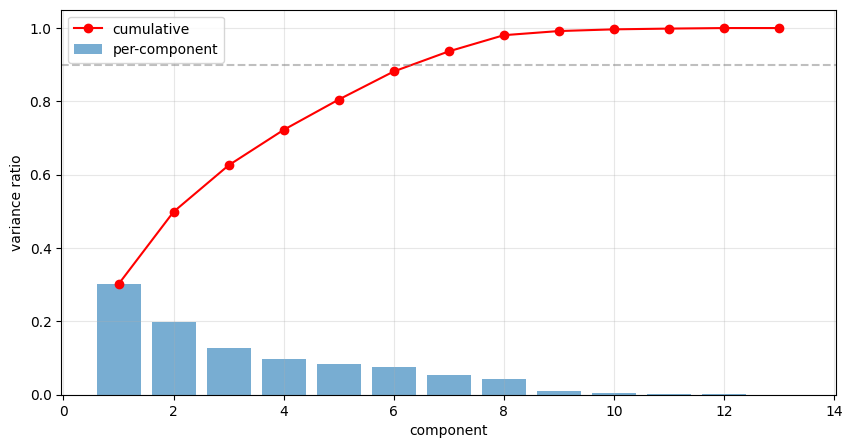

PC1  var=0.3015 cum=0.3015
PC2  var=0.1974 cum=0.4989
PC3  var=0.1268 cum=0.6257
PC4  var=0.0966 cum=0.7223
PC5  var=0.0826 cum=0.8049
PC6  var=0.0767 cum=0.8816
PC7  var=0.0548 cum=0.9364
PC8  var=0.0441 cum=0.9805
PC9  var=0.0113 cum=0.9918
PC10 var=0.0046 cum=0.9965
PC11 var=0.0020 cum=0.9985
PC12 var=0.0015 cum=1.0000
PC13 var=0.0000 cum=1.0000


In [2]:
pca = PCA()
pca.fit(X)

var = pca.explained_variance_ratio_
cum = np.cumsum(var)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(var) + 1), var, alpha=0.6, label='per-component')
plt.plot(range(1, len(var) + 1), cum, 'o-', color='red', label='cumulative')
plt.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('component')
plt.ylabel('variance ratio')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for i, (v, c) in enumerate(zip(var, cum), 1):
    print(f"PC{i:<2} var={v:.4f} cum={c:.4f}")

## 2D projection

First two PCs as a scatter — quick view of the dominant axes of variation. Color by the original target to see how much of the price signal lives in those two directions.

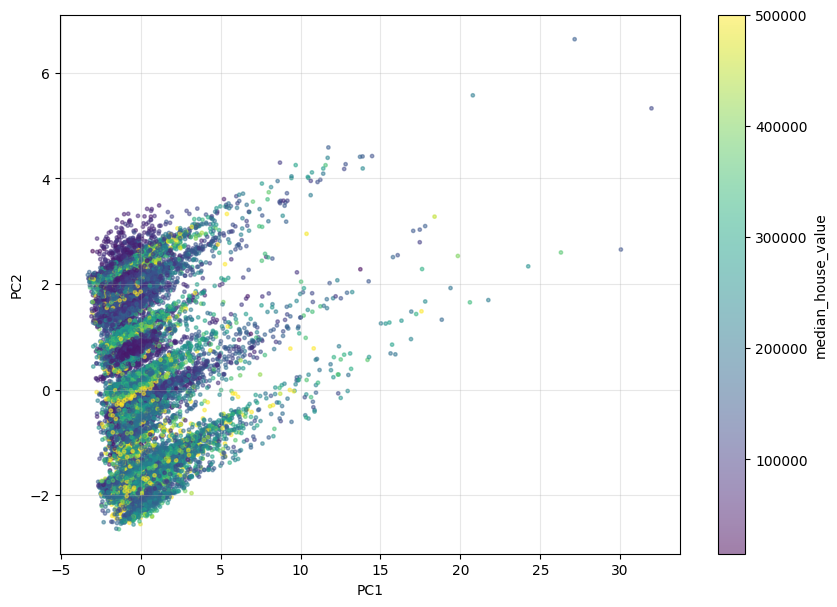

In [3]:
pca2 = PCA(n_components=2)
Z2 = pca2.fit_transform(X)

plt.figure(figsize=(10, 7))
sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=target, cmap='viridis', s=6, alpha=0.5)
plt.colorbar(sc, label='median_house_value')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.show()

## 3D projection

Same idea with three components. Sometimes structure that's invisible in 2D pops out once you can rotate it.

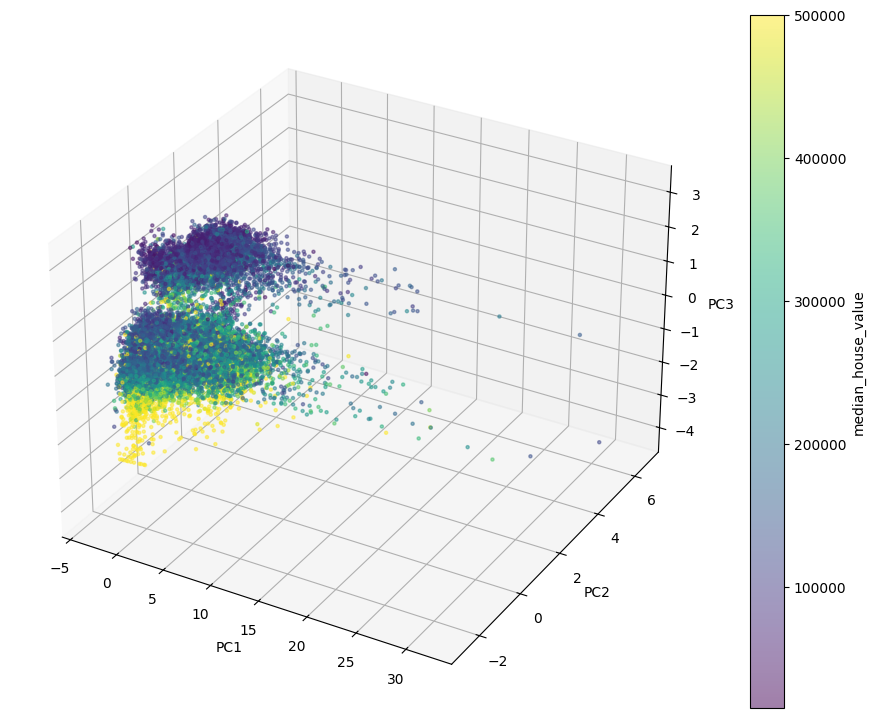

In [4]:
pca3 = PCA(n_components=3)
Z3 = pca3.fit_transform(X)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(projection='3d')
sc = ax.scatter(Z3[:, 0], Z3[:, 1], Z3[:, 2], c=target, cmap='viridis', s=5, alpha=0.5)
fig.colorbar(sc, label='median_house_value')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

## Component loadings

Each PC is a linear combination of the original features. Loadings show which features each PC is mostly capturing — usually PC1 is something like a "size" axis (population, total_rooms, total_bedrooms move together) and PC2 picks up geography.

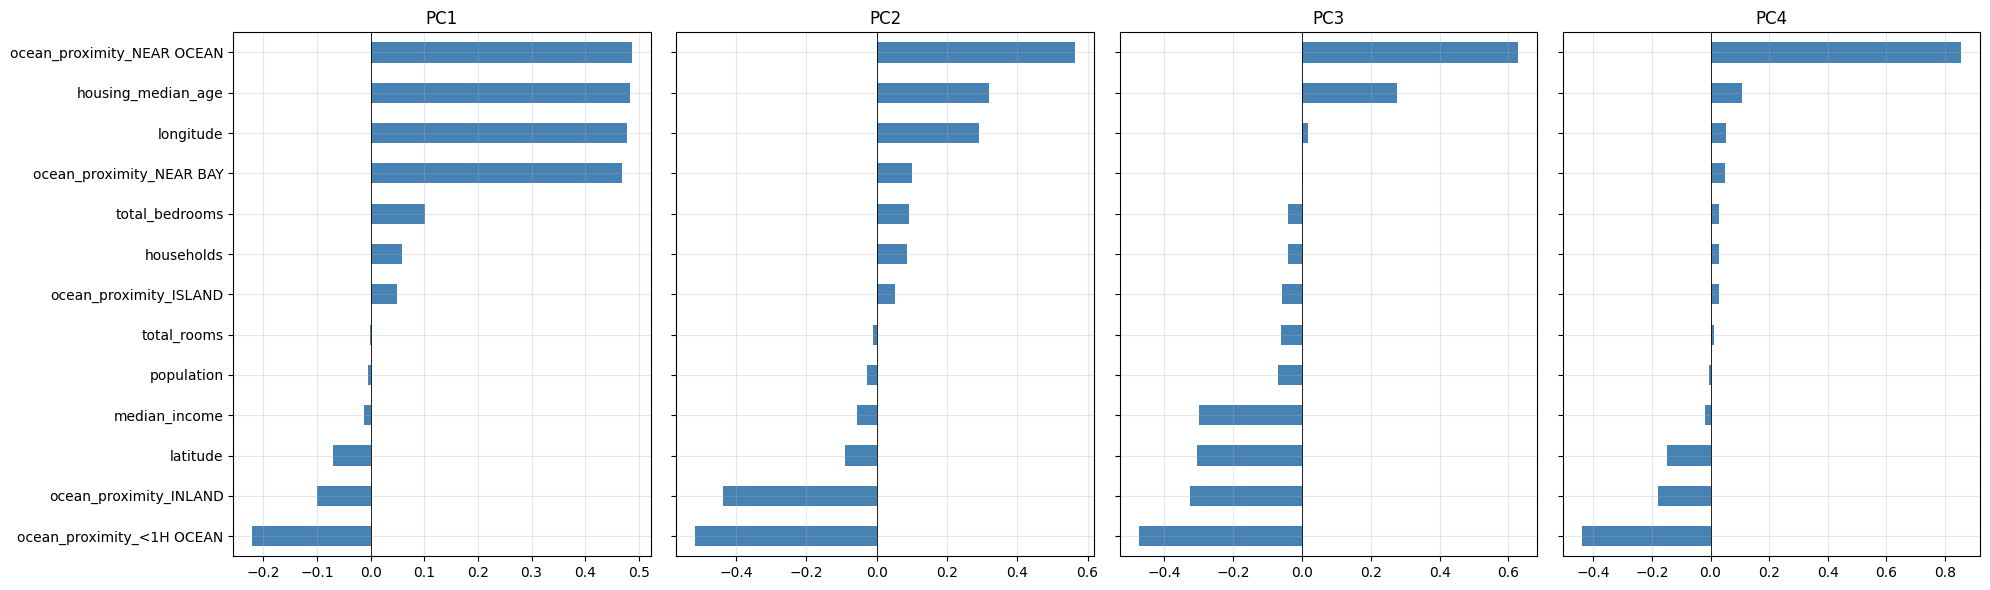

                              PC1    PC2    PC3    PC4
longitude                   0.102 -0.515  0.277  0.053
latitude                   -0.100  0.564 -0.062 -0.148
housing_median_age         -0.221 -0.027 -0.325  0.108
total_rooms                 0.478  0.101 -0.057  0.013
total_bedrooms              0.484  0.091 -0.040  0.030
population                  0.469  0.052 -0.039 -0.004
households                  0.487  0.085 -0.070  0.028
median_income               0.048 -0.089 -0.306 -0.018
ocean_proximity_<1H OCEAN   0.058 -0.436 -0.299 -0.440
ocean_proximity_INLAND     -0.013  0.290  0.627 -0.181
ocean_proximity_ISLAND     -0.006 -0.009  0.004  0.028
ocean_proximity_NEAR BAY   -0.071  0.320 -0.475  0.050
ocean_proximity_NEAR OCEAN -0.001 -0.057  0.017  0.856


In [5]:
loadings = pd.DataFrame(pca.components_[:4].T, index=feature_names,
                        columns=[f'PC{i+1}' for i in range(4)])

fig, axs = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
for i, ax in enumerate(axs):
    loadings.iloc[:, i].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'PC{i+1}')
    ax.axvline(0, color='k', lw=0.6)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(loadings.round(3))

## Reconstruction error vs k

Project to $k$ components then back to the original space:

$$\hat X = X V_k V_k^T, \quad \text{error} = \|X - \hat X\|_F^2$$

The curve mirrors the explained-variance plot — adding components monotonically reduces error.

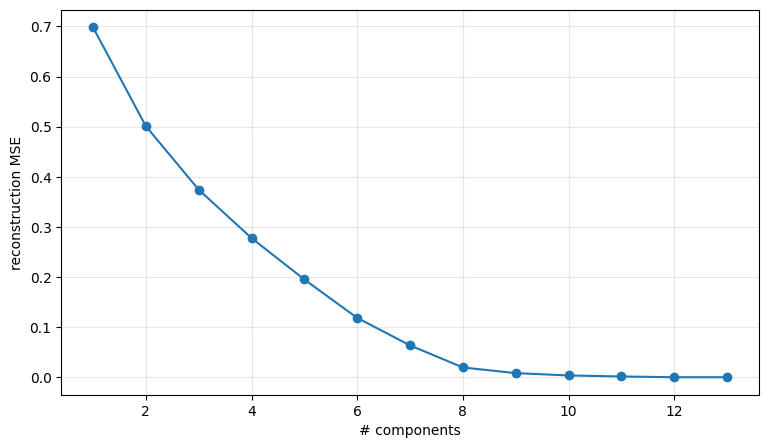

k=1  mse=0.698494
k=2  mse=0.501103
k=3  mse=0.374333
k=4  mse=0.277693
k=5  mse=0.195077
k=6  mse=0.118405
k=7  mse=0.063589
k=8  mse=0.019458
k=9  mse=0.008177
k=10 mse=0.003527
k=11 mse=0.001482
k=12 mse=0.000000
k=13 mse=0.000000


In [6]:
ks = list(range(1, X.shape[1] + 1))
errors = []

for k in ks:
    p = PCA(n_components=k)
    Z = p.fit_transform(X)
    X_rec = p.inverse_transform(Z)
    err = np.mean((X - X_rec) ** 2)
    errors.append(err)

plt.figure(figsize=(9, 5))
plt.plot(ks, errors, 'o-')
plt.xlabel('# components')
plt.ylabel('reconstruction MSE')
plt.grid(alpha=0.3)
plt.show()

for k, e in zip(ks, errors):
    print(f"k={k:<2} mse={e:.6f}")

## From-scratch PCA

Center the data, take the SVD, keep the top k right-singular vectors. Matches `src/rice_ml/unsupervised_ml/pca.py`. Should produce identical projections to sklearn up to a sign flip on each component.

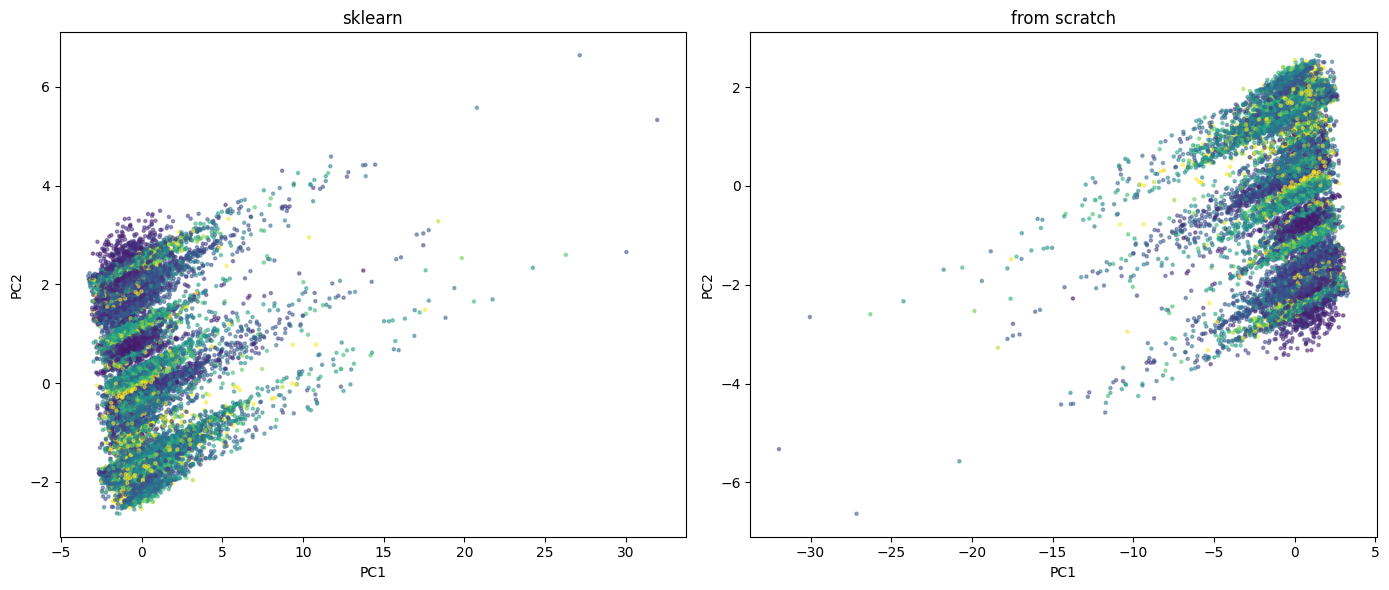

Explained variance (scratch top 2): [0.3015 0.1974]


In [7]:
from rice_ml.unsupervised_ml import PCA as PCAScratch

scratch = PCAScratch(n_components=2).fit(X)
Z_scratch = scratch.transform(X)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].scatter(Z2[:, 0], Z2[:, 1], c=target, cmap='viridis', s=5, alpha=0.5)
axs[0].set_title('sklearn')
axs[1].scatter(Z_scratch[:, 0], Z_scratch[:, 1], c=target, cmap='viridis', s=5, alpha=0.5)
axs[1].set_title('from scratch')
for ax in axs:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

print("Explained variance (scratch top 2):", scratch.explained_variance_ratio_.round(4))